In [1]:
# Stage 1 — Dataset Loading

import pandas as pd

DATA_PATH = "/kaggle/input/datasets/muhammadaliparacha/lab-4-task-004/Wholesale customers data.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.head())

(440, 8)
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


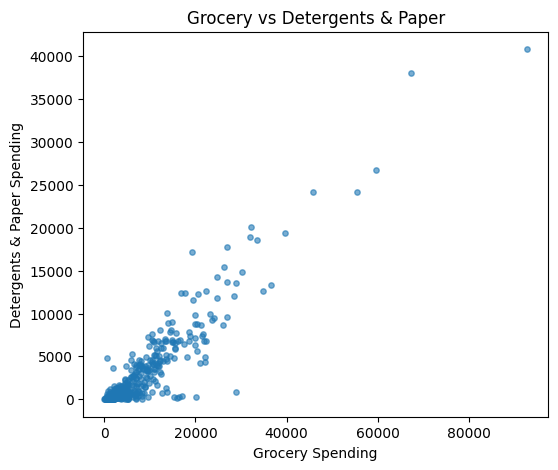

In [2]:
# Stage 2 — Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.scatter(
    df["Grocery"],
    df["Detergents_Paper"],
    s=15,
    alpha=0.6
)

plt.xlabel("Grocery Spending")
plt.ylabel("Detergents & Paper Spending")
plt.title("Grocery vs Detergents & Paper")

plt.show()

In [3]:
# Stage 3 — Preprocessing

from sklearn.preprocessing import StandardScaler

feature_cols = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

X = df[feature_cols].values

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873 -0.06633906]
 [-0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684  0.08915105]
 [-0.44702926  0.40853771 -0.0281571  -0.13753572  0.13323164  2.24329255]
 [ 0.10011141 -0.62401993 -0.3929769   0.6871443  -0.49858822  0.09341105]
 [ 0.84023948 -0.05239645 -0.07935618  0.17385884 -0.23191782  1.29934689]]


In [4]:
# Stage 4 — Training

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

print("K-Means training completed.")

K-Means training completed.


In [5]:
# Stage 5 — Testing

df["Cluster"] = kmeans.predict(X_scaled)

print(df["Cluster"].value_counts())

Cluster
1    393
0     45
2      2
Name: count, dtype: int64


In [6]:
# Stage 6 — Validation

comparison = pd.crosstab(
    df["Cluster"],
    df["Channel"]
)

print(comparison)

Channel    1   2
Cluster         
0          1  44
1        295  98
2          2   0
